Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you :
- Fill in your name
- Fill any place that says `YOUR CODE HERE` (you will be graded based on this code, any extra cells you code will not be graded)
- Delete  `NotImplementedError()` exception once you have completed your implementation

In [1]:
NAME = "NGUYEN THI THU TRANG"

In [2]:
import pytest

---

# **Problem 1: BinaryTree class (3)**

Implement a `Node` class and a `BinaryTree` class with the following specifications:

**Node Class**

Each node should contain:
- Its value
- Parent
- Left child
- Right child

**BinaryTree Class**

The `BinaryTree` class should include common methods such as:
- `add_left(node, value)`: Adds a left child to a specified node. Raises an Exception if the node already has a left child.
- `add_right(node, value)`: Adds a right child to a specified node. Raises an Exception if the node already has a right child.
- `is_root(node)`: Checks if a node is the root of the tree.
- `is_leaf(node)`: Checks if a node is a leaf (no children).
- `check_ancestor(node1, node2)`: Checks if `node1` is an ancestor of `node2`.

Additionally, implement:
- `height(node)`: Method to find the height of the tree from a given node.
- `depth(node)`: Method to find the depth of a given node in the tree.

**Note:**
- In the `add_left` and `add_right` methods, you should `raise Exception` if the node already has a left or right child respectively.


In [3]:
class Node:
    def __init__(self, value, parent=None, left=None, right=None):
        self.value = value
        self.parent = parent
        self.left = left
        self.right = right

    def __repr__(self):
        return str(self.value)

In [4]:
class BinaryTree:
    def __init__(self, root = None):
        self.root = root
        self.pre, self.post, self.in_, self.bf = [], [], [], []
        
    def add_left(self, p_node: Node, c_node: Node):
        if p_node.left is None:
            p_node.left = c_node
            c_node.parent = p_node
        else:
            raise Exception("This node already has a left child.")

    def add_right(self, p_node: Node, c_node: Node):
        if p_node.right is None:
            p_node.right = c_node
            c_node.parent = p_node
        else:
            raise Exception("This node already has a right child.")

    def is_root(self, node: Node):
        return self.root == node

    def is_leaf(self, node: Node):
        return node is not None and node.left is None and node.right is None

    def check_ancestor(self, node1: Node, node2: Node):
        if node1.left == node2 or node1.right == node2:
            return True
        return False

    def depth(self, node: Node):
        if node is None:
            return 
        
        depth = 0

        while node != self.root and node:
            node = node.parent
            depth += 1
        
        return depth

    def height(self, node: Node):
        if node is None:
            return -1
        left_height = self.height(node.left)
        right_height = self.height(node.right)

        return max(left_height, right_height) + 1

    def __str__(self):
        def update(root, r, c):
            if root is None:
                return
            ans[r][c] = str(root.value)
            update(root.left, r + 1, c - 2 ** (height - 1  - r - 1))
            update(root.right, r + 1, c + 2 ** (height - 1 - r - 1))

        height, width = self.height(self.root) + 1, 2 ** (self.height(self.root) + 1) - 1
        ans = [[" "] * width for _ in range(height)]
        update(self.root, 0, (width - 1) // 2)
        return '\n'.join([' '.join(row) for row in ans])


In [5]:
# Verification - Creating the given tree structure
n1 = Node(1)
n2 = Node(2)
n3 = Node(3)
n4 = Node(4)
n5 = Node(5)
n6 = Node(6)
n7 = Node(7)
n8 = Node(8)
n9 = Node(9)

tree = BinaryTree(n1)
tree.add_left(n1, n2)
tree.add_right(n1, n3)
tree.add_left(n2, n4)
tree.add_right(n2, n5)
tree.add_left(n5, n7)
tree.add_right(n5, n8)
tree.add_left(n3, n6)
tree.add_left(n6, n9)
print(tree)

              1              
      2               3      
  4       5       6          
        7   8   9            


In [6]:
assert tree.is_root(n1) == True
assert tree.is_root(n9) == False
assert tree.is_leaf(n6) == False
assert tree.is_leaf(n9) == True
assert tree.check_ancestor(n2, n5) == True
assert tree.check_ancestor(n2, n9) == False

In [7]:
assert tree.depth(n5) == 2
assert tree.height(n5) == 1
assert tree.depth(n9) == 3
assert tree.height(n9) == 0

In [8]:
with pytest.raises(Exception):
    tree.add_left(n5)
    tree.add_right(n2)

# **Problem 2: Find Largest Value in Each Tree Row (2)**

Given the root of a binary tree, return an array of the largest value in each row of the tree.

**Example:**

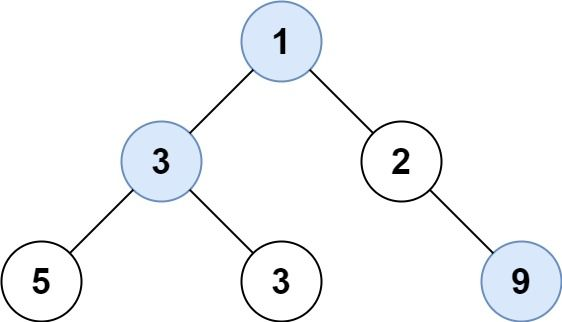


```
Input: root = [1,3,2,5,3,null,9]
Output: [1,3,9]
```



In [9]:
from queue import deque
def largestValues(root: Node):
    if not root:
        return []
    result = []
    level = deque()
    level.append(root)

    while len(level) != 0:
        level_size = len(level)
        temp = []

        for _ in range(level_size):
            node = level.popleft()
            temp.append(node.value)

            if node.left:
                level.append(node.left)
            if node.right:
                level.append(node.right)
        
        result.append(max(temp))
    
    return result


In [10]:
n1 = Node(1)
n2 = Node(3)
n3 = Node(2)
n4 = Node(5)
n5 = Node(3)
n6 = Node(9)

tree = BinaryTree(n1)
tree.add_left(n1, n2)
tree.add_right(n1, n3)
tree.add_left(n2, n4)
tree.add_right(n2, n5)
tree.add_right(n3, n6)

print(tree)
assert largestValues(n1) == [1, 3, 9]

      1      
  3       2  
5   3       9


In [11]:
n1 = Node(10)
n2 = Node(20)
n3 = Node(30)
n4 = Node(40)

tree = BinaryTree(n1)
tree.add_left(n1, n2)
tree.add_left(n2, n3)
tree.add_left(n3, n4)

print(tree)
assert largestValues(n1) == [10, 20, 30, 40]


              10              
      20                      
  30                          
40                            


In [12]:
# DO NOT DELETE THIS CELL

In [13]:
# DO NOT DELETE THIS CELL

# **Problem 3: Two Sum (2)**

Given a list of integers `nums` and an integer `target`, returns a tuple of the first pair of indices $(i,j)$ such that `nums[i] + nums[j] == target`. If no such pair exists, returns $-1$.

**Note that:** Your solution will be graded based on the time complexity. Here is the breakdown:

| Complexity                | Points |
|---------------------------|--------|
| $O(N)$                    | 2      |
| $O(N \log N)$             | 1.5    |
| $O(N^2)$                  | 1      |


**Example 1:**
```
Input: nums = [5, 2, 3], target = 8
Output: [0, 2]
```
**Example 2:**
```
Input: nums = [3, 2, 4], target = 6
Output: [1, 2]
```

In [14]:
def twoSum(nums: list[int], target: int):
    seen = {}  
    
    for i in range(len(nums)):
        complement = target - nums[i]
        
        if nums[i] in seen:
            return (seen[nums[i]], i)
            
        seen[complement] = i
        
    return -1


In [15]:
assert twoSum([5, 2, 3], 8) == (0, 2)
assert twoSum([3, 2, 4], 6) == (1, 2)

In [16]:
# DO NOT DELETE THIS CELL

# **Problem 4: Parking System (2)**

Vinh is a boss of a small parking lot that has only 5 spots, numbered 0 through 4. To decide where a car should park, he uses a simple rule:

1. Take the car's license plate (a string)

2. Convert each character to its ASCII number using ord() function

    - For example: ord('A') = 65, ord('B') = 66.

4. Add them up, then take the sum modulo 5 to get the parking spot

   - Parking spot of license plate 'AB' = (65 + 66) % 5 = 1

The system must keep a history of all license plates that parked in each spot, in order.

At the end of the day, print out the full list of license plates that tried to park in each spot.

In [17]:
class StrictParkingLot:
    def __init__(self):
        """
        Initializes the following attributes:
        - current_parking: a list where each index represents a spot (1-5), initially empty (None).
        - history: a list of lists, where each sublist stores the license plates that parked at that spot.
        """
        self.size = 5
        self.current_parking = [None] * self.size
        self.history = [[] for _ in range(self.size)]

    def _hash_plate(self, license_plate: str) -> int:
        """
        Converts a license plate string into a parking spot index using ASCII hashing.

        Parameters:
        - license_plate (str): The license plate to hash.

        Returns:
        - int: The spot index (0 to 4) based on the ASCII sum modulo 5.
        """
        current = 0
        for c in license_plate:
            current += ord(c)
        return current % 5

    def is_current_parking(self, license_plate: str) -> bool:
        """
        Checks whether a car with the given license plate is currently parked.

        Parameters:
        - license_plate (str): The license plate to check.

        Returns:
        - bool: True if the car is currently parked, False otherwise.
        """
        if self.current_parking[self._hash_plate(license_plate)]:
            return True
        return False

    def attempt_park(self, license_plate: str) -> bool:
        """
        Attempts to park a car with the given license plate.

        Parameters:
        - license_plate (str): The license plate of the car trying to park.

        Returns:
        - bool: True if the car was successfully parked, False if the spot is occupied.

        Raises:
        - raiseExceptions: If the car is already parked.
        """
        license = self._hash_plate(license_plate)
        if self.current_parking[license] == license_plate:
            raise Exception("The car is already parked")
        elif self.is_current_parking(license_plate):
            return False
        else:
            self.current_parking[license] = license_plate
            self.history[license].append(license_plate)
            return True
        

    def leave(self, spot_number: int):
        """
        Frees the parking spot with the given 1-based number.

        Parameters:
        - spot_number (int): The spot number (0-4).

        Action:
        - Sets the corresponding spot in current_parking to None if it's occupied.
        """
        if self.current_parking[spot_number]:
            self.current_parking[spot_number] = None

    def parking_history(self) -> list:
        return self.history

    def print_history(self):
        for i in range(self.size):
            print(f"Spot {i}: {self.history[i]}")


In [18]:
lot = StrictParkingLot()

# Test 1: New car parking
assert lot.attempt_park("38A 123.45") == True
assert lot.current_parking[lot._hash_plate("38A 123.45")] == "38A 123.45"
lot.print_history()
print('-' * 20)

# Test 2: New car parking
assert lot.attempt_park("30A 555.55") == True
lot.print_history()
print('-' * 20)

# Test 3: New car parking failed
assert lot.attempt_park("34C 888.99") == False
assert lot.current_parking[lot._hash_plate("34C 888.99")] == "38A 123.45"
lot.print_history()
print('-' * 20)

# Test 4: New car parking
assert lot.attempt_park("34C 888.98") == True
lot.print_history()
print('-' * 20)

Spot 0: ['38A 123.45']
Spot 1: []
Spot 2: []
Spot 3: []
Spot 4: []
--------------------
Spot 0: ['38A 123.45']
Spot 1: []
Spot 2: ['30A 555.55']
Spot 3: []
Spot 4: []
--------------------
Spot 0: ['38A 123.45']
Spot 1: []
Spot 2: ['30A 555.55']
Spot 3: []
Spot 4: []
--------------------
Spot 0: ['38A 123.45']
Spot 1: []
Spot 2: ['30A 555.55']
Spot 3: []
Spot 4: ['34C 888.98']
--------------------


In [19]:
# Test 5: Car leaving
lot.leave(0)

# Test 6: New cars parking
assert lot.attempt_park("34C 888.99") == True
assert lot.attempt_park("37A 321.51") == True
assert lot.attempt_park("29A 898.85") == True
lot.print_history()
print('-' * 20)

# Test 7: Cars leaving
for i in range(5):
  lot.leave(i)

# Test 8: New cars parking
assert lot.attempt_park("29A 100.01") == True
assert lot.attempt_park("34A 010.01") == True
assert lot.attempt_park("35A 001.01") == True
assert lot.attempt_park("36A 000.11") == True
assert lot.attempt_park("37A 001.15") == True
lot.print_history()
print('-' * 20)

# Test 9: Car is parking but attempting to park
with pytest.raises(Exception):
  lot.attempt_park("37A 001.15")

# Test 10: Today parking history
assert lot.parking_history() == [['38A 123.45', '34C 888.99', '36A 000.11'],
                                ['37A 321.51', '37A 001.15'],
                                ['30A 555.55', '29A 100.01'],
                                ['29A 898.85', '34A 010.01'],
                                ['34C 888.98', '35A 001.01']]


Spot 0: ['38A 123.45', '34C 888.99']
Spot 1: ['37A 321.51']
Spot 2: ['30A 555.55']
Spot 3: ['29A 898.85']
Spot 4: ['34C 888.98']
--------------------
Spot 0: ['38A 123.45', '34C 888.99', '36A 000.11']
Spot 1: ['37A 321.51', '37A 001.15']
Spot 2: ['30A 555.55', '29A 100.01']
Spot 3: ['29A 898.85', '34A 010.01']
Spot 4: ['34C 888.98', '35A 001.01']
--------------------


In [20]:
# DO NOT DELETE THIS CELL

# Problem 5: Sum of all elements between k1’th and k2’th smallest elements (1)

Given an array of integers and two numbers k1 and k2. Find the sum of all elements between (by index) given two k1’th and k2’th smallest elements of the array. It may be assumed that (1 <= k1 < k2 <= n) and all elements of array are distinct.

Examples:
```
Input : arr = [20, 8, 22, 4, 12, 10, 14],  k1 = 3,  k2 = 6  
Output : 46          
         3rd smallest element is 10 at index = 5.
         6th smallest element is 20 at index = 0.
         Sum of all element between index 0 and 5 is:
         8 + 22 + 4 + 12 = 46
```

You may or may not use Heapq. Heapq instruction:
- heappush(heap, item)
   - Adds a new item to the heap while maintaining the heap property.
Usage example: heappush(my_heap, 5)

- heappop(heap)
  - Removes and returns the smallest item from the heap.
Usage example: smallest = heappop(my_heap)

- heapify(x)
  - Transforms a list into a heap in place, in linear time.
Usage example: heapify(my_list)



In [21]:
import heapq
def sumAllElements(arr: list[int], k1: int, k2: int) -> int:
    current = []
    my_list = []
    for num in arr:
        my_list.append(num)
        # heapq.heappush(my_list, num)

    for index, num in enumerate(arr):
        current.append([num, index])
    
    # heapq.heapify(my_list)
    my_list.sort()
    num1 = my_list[k1 - 1]
    num2 = my_list[k2 - 1]

    ans = 0

    for i in range(len(current)):
        if current[i][0] == num1:
            index1 = i
        if current[i][0] == num2:
            index2 = i

    if index1 < index2:
        for i in range(index1 + 1, index2):
            ans += arr[i]
    elif index2 < index1:
        for i in range(index2 + 1, index1):
            ans += arr[i]
        
    return ans
    

In [22]:
assert sumAllElements([20, 8, 22, 4, 12, 10, 14], 3, 6) == 46
assert sumAllElements([1, 3, 5, 11, 15, 7, 9], 2, 5) == 38

In [23]:
# DO NOT DELETE THIS CELL